<div align="center">

# **DASC-6010 Project**  
## **Bitcoin Price Effect on Altcoins**  
### **Group AnAyltics**

</div>

# 1. Connect to Database & Load the Data

In [1]:
import pandas as pd
import numpy as np
import sqlalchemy
from sqlalchemy import create_engine

username = 'postgres'
password = 'postgres'
host     = 'localhost'     
port     = '9432'           
database = 'anayltics'

engine_str = f"postgresql://{username}:{password}@{host}:{port}/{database}"
engine = create_engine(engine_str)

query_btc = """
    SELECT moment, high, open, low, close, volume
    FROM public.kline_btc
    ORDER BY moment ASC;
"""
df_btc = pd.read_sql(query_btc, con=engine)

df_ada = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_ada ORDER BY moment ASC", con=engine)
df_bnb = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_bnb ORDER BY moment ASC", con=engine)
df_eth = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_eth ORDER BY moment ASC", con=engine)
df_sol = pd.read_sql("SELECT moment, high, open, low, close, volume FROM public.kline_sol ORDER BY moment ASC", con=engine)


# 2. Clean & Transform Data

### 2.a Convert moment to DateTime

In [2]:
for df in [df_btc, df_ada, df_bnb, df_eth, df_sol]:
    df['moment'] = pd.to_datetime(df['moment'], unit='ms') 

### 2.b Check for missing values, duplicates, etc.

In [3]:
for df in [df_btc, df_ada, df_bnb, df_eth, df_sol]:
    df.drop_duplicates(subset=['moment'], inplace=True)

### 2.c Check consistency of the data

In [4]:
def print_dataframe_info(name, df):
    if df.empty:
        print(f"\033[91m{name}: DataFrame is EMPTY\033[0m")
        return
    
    start_moment = df['moment'].min()
    end_moment = df['moment'].max()
    length = len(df)

    print(f"\033[96m{name}:\033[0m")
    print(f"  📅 Start: {start_moment}")
    print(f"  📅 End  : {end_moment}")
    print(f"  🔢 Length: {length}")
    print("-" * 40)

print_dataframe_info("BTC", df_btc)
print_dataframe_info("ADA", df_ada)
print_dataframe_info("BNB", df_bnb)
print_dataframe_info("ETH", df_eth)
print_dataframe_info("SOL", df_sol)

BTC:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2025-02-19 14:45:00
  🔢 Length: 144958
----------------------------------------
ADA:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2025-02-19 14:45:00
  🔢 Length: 144958
----------------------------------------
BNB:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2025-02-19 14:45:00
  🔢 Length: 144958
----------------------------------------
ETH:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2025-02-19 14:45:00
  🔢 Length: 144958
----------------------------------------
SOL:
  📅 Start: 2020-12-31 21:00:00
  📅 End  : 2025-02-19 14:45:00
  🔢 Length: 144958
----------------------------------------


# 3. Exploratory Data Analysis

### 3.a Basic Statistics

In [5]:
def display_descriptions(dfs, names):
    descriptions = {name: df.describe() for name, df in zip(names, dfs)}
    for name, desc in descriptions.items():
        print(f"\n{'='*20} {name.upper()} DESCRIPTION {'='*20}")
        print(desc.to_string())

dfs = [df_btc, df_ada, df_bnb, df_eth, df_sol]
names = ["BTC", "ADA", "BNB", "ETH", "SOL"]

display_descriptions(dfs, names)


==================== BTC DESCRIPTION ====================
                              moment           high           open            low          close         volume
count                         144958  144958.000000  144958.000000  144958.000000  144958.000000  144958.000000
mean   2023-01-26 10:35:54.739994368   44532.901839   44446.867105   44356.848975   44446.921831       7.150319
min              2020-12-31 21:00:00   15705.330000   15653.630000   15486.740000   15650.780000       0.000000
25%              2022-01-13 20:03:45   27589.100000   27548.302500   27500.000000   27547.185000       0.313076
50%              2023-01-26 08:07:30   40975.400000   40860.265000   40750.565000   40860.215000       1.585929
75%              2024-02-08 02:56:15   58900.000000   58781.952500   58663.145000   58782.107500       6.278210
max              2025-02-19 14:45:00  138070.000000  108780.560000  108102.890000  108901.820000    1035.045328
std                              NaN   21089.

# 📊 Summary of Cryptocurrency Closing Prices & Trading Volume

## **BTC (Bitcoin)**
- **Average Close Price**: ~44,000  
- **Price Range**: 15,600 – 108,900  
- **Volatility (Std Dev)**: ~21,000  
- **Trading Volume**: Can exceed **1,000** in some hours  
- **Insight**: Significant price fluctuations indicate high volatility in the BTC market.

---

## **ADA (Cardano)**
- **Average Close Price**: ~0.76  
- **Price Range**: 0.17 – 3.09  
- **Volatility (Std Dev)**: ~0.56  
- **Trading Volume**: Peaks above **2.8 million**  
- **Insight**: Noticeable price swings and sharp spikes in trading activity.

---

## **BNB (Binance Coin)**
- **Average Close Price**: ~387  
- **Price Range**: 35 – 785  
- **Insight**: Reflects substantial growth potential.  
- **Trading Volume**: Occasionally surpasses **9,000**, indicating bursts of high trading intensity.

---

## **ETH (Ethereum)**
- **Average Close Price**: ~2,423  
- **Price Range**: 715 – 4,850  
- **Volatility (Std Dev)**: ~870  
- **Trading Volume**: Max close to **4,000**  
- **Insight**: Periods of strong market engagement with considerable price swings.

---

## **SOL (Solana)**
- **Average Close Price**: ~85  
- **Price Range**: 1.49 – 294  
- **Insight**: Highlights rapid expansion in value.  
- **Trading Volume**: Peaks over **67,000**, indicating periods of intense trading.

---

📌 **Key Takeaways**:  
- **BTC** and **ETH** exhibit **high volatility** but remain dominant.  
- **ADA** and **SOL** have **relatively lower average prices** but show potential for rapid growth.  
- **BNB** demonstrates **strong market engagement** with frequent price fluctuations.  
- **Trading volume spikes** indicate moments of heightened interest and liquidity.  

### 3.b Correlations

In [6]:
combined_df = pd.DataFrame({
    'btc_close': df_btc['close'],
    'ada_close': df_ada['close'],
    'bnb_close': df_bnb['close'],
    'eth_close': df_eth['close'],
    'sol_close': df_sol['close']
})
correlation_matrix = combined_df.corr()
print(correlation_matrix)

           btc_close  ada_close  bnb_close  eth_close  sol_close
btc_close   1.000000   0.295129   0.828901   0.735033   0.839604
ada_close   0.295129   1.000000   0.326586   0.592473   0.340496
bnb_close   0.828901   0.326586   1.000000   0.820932   0.863627
eth_close   0.735033   0.592473   0.820932   1.000000   0.855022
sol_close   0.839604   0.340496   0.863627   0.855022   1.000000


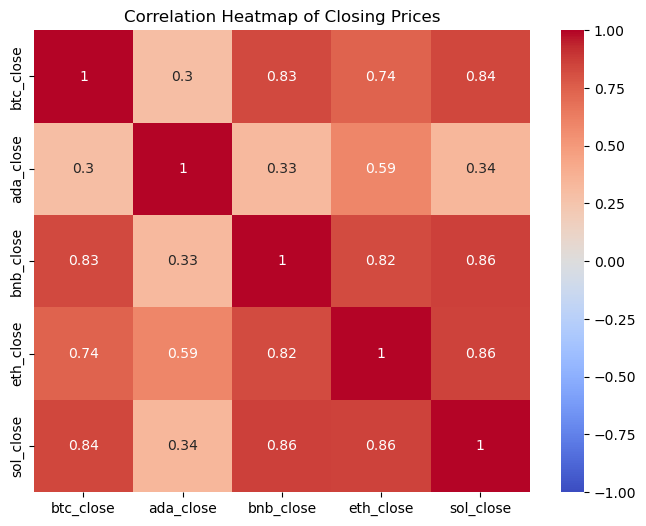

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Closing Prices")
plt.show()

# 🔗 **Cryptocurrency Correlations with BTC & Each Other**

## **📉 BTC Correlations**
- **BNB (0.83)** & **SOL (0.84)**:  
  - These coins **move closely** with Bitcoin, reflecting strong market synchronization.
- **ETH (0.74)**:  
  - Also **strongly correlated** with BTC, but slightly less than BNB and SOL.
- **ADA (0.30)**:  
  - Shows **only a modest correlation**, indicating more **independent price movements**.

---

## **📊 Inter-Altcoin Correlations**
- **BNB & SOL (0.86)**:  
  - The **strongest correlation**, suggesting these two assets often behave **similarly** in market trends.
- **ETH & BNB (0.82) / ETH & SOL (0.86)**:  
  - Ethereum aligns well with major altcoins, reinforcing its **role as a key altcoin driver**.
- **ADA & ETH (0.59)**:  
  - ADA follows **broader market trends** but maintains a degree of **independence** from other altcoins.

---

## **📌 Key Insights**
- **BNB & SOL** behave **most similarly**, while **ADA** tends to be **less connected** to major market moves.
- **ETH** serves as a **bridge** between BTC and other altcoins, sharing strong correlations across multiple assets.
- **Bitcoin’s price shifts heavily impact BNB, SOL, and ETH**, but ADA remains a **less predictable player** in the crypto market.

### 3.c Distribution Analysis

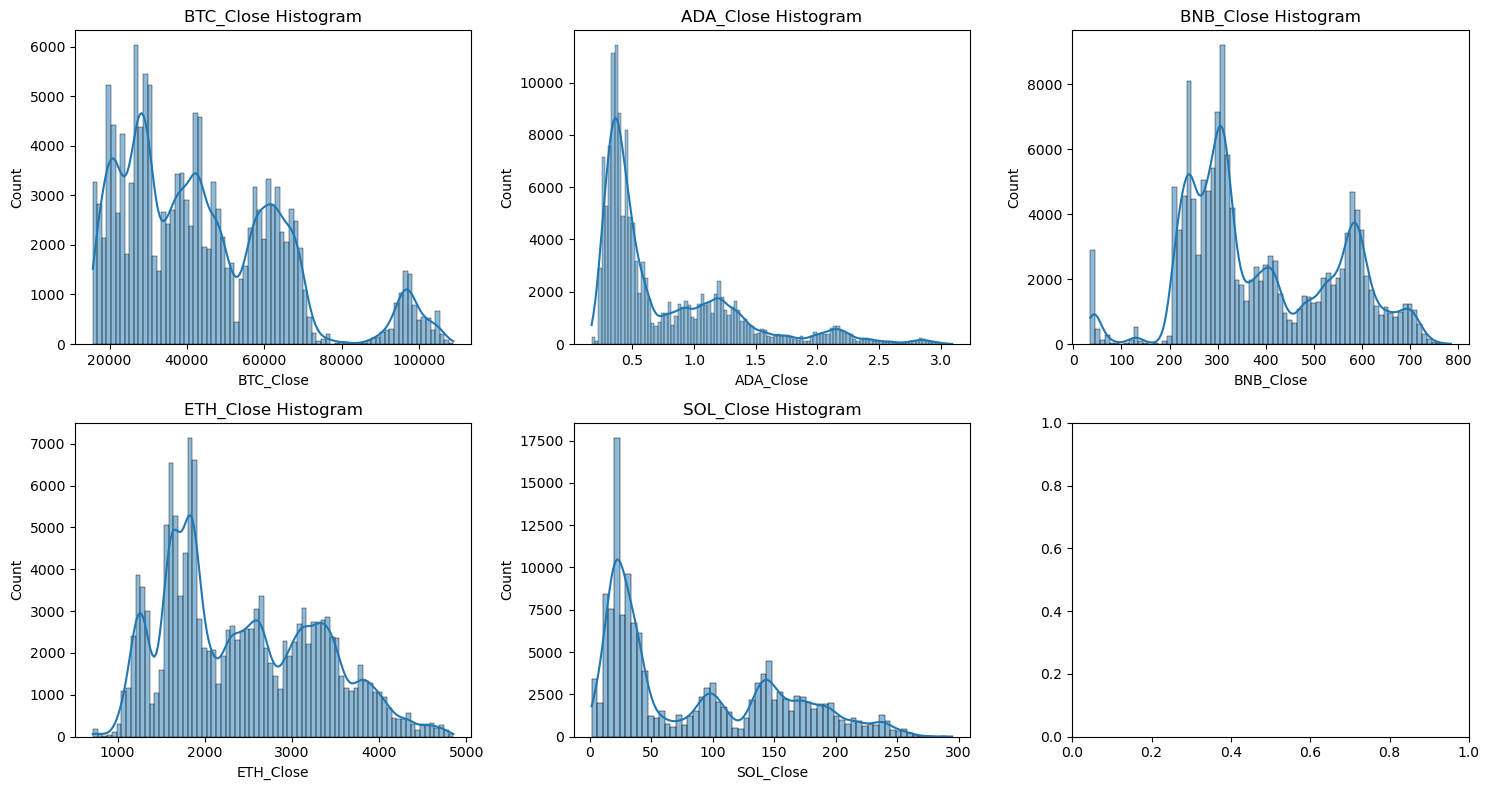

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

df_combined = pd.DataFrame({
    'BTC_Close': df_btc['close'],
    'ADA_Close': df_ada['close'],
    'BNB_Close': df_bnb['close'],
    'ETH_Close': df_eth['close'],
    'SOL_Close': df_sol['close'],
})

coins = ['BTC_Close', 'ADA_Close', 'BNB_Close', 'ETH_Close', 'SOL_Close']
for i, coin in enumerate(coins):
    sns.histplot(df_combined[coin], kde=True, ax=axes[i])
    axes[i].set_title(f"{coin} Histogram")
    
plt.tight_layout()
plt.show()

# 📊 **Histogram Analysis of Crypto Price Distributions**

## **🏆 Right-Skewed, Multi-Modal Distributions**
All five assets display **right-skewed** and **multi-modal** price distributions, which reflect **crypto market cycles** of rapid price appreciation followed by corrections.  

---

## **📈 BTC: Multiple Bull Cycles**
- Peaks primarily in the **20k–60k range**, but also extends toward **six figures**.
- Indicates **multiple bull runs**, with strong accumulation phases.

## **📉 ETH: Volatile but Upward Trending**
- Shows **distinct price clusters** from **under 1k to nearly 5k**.
- Reflects Ethereum's **strong growth trajectory** alongside market volatility.

## **🔹 BNB & SOL: Expanding Price Ranges**
- **BNB** spans **low double digits to $700+,** with key clusters around **300–400**.
- **SOL** follows a similar pattern, starting low and reaching **high hundreds**.
- Suggest **strong price expansions** over time.

## **🟦 ADA: More Concentrated but Still Surging**
- **Heavily centers around 0.5**, showing strong historical support.
- Has a **long right tail**, peaking above **3**, aligning with market-wide surges.

---

## **📌 Key Insights**
- Crypto prices exhibit **non-normal** distributions, dominated by **boom-and-bust cycles**.
- **BTC & ETH** show **strong uptrends** with multiple price clusters.
- **BNB & SOL** have seen **steady price expansions**, reflecting their growing adoption.
- **ADA**, while less volatile, still experiences **episodic surges** during market rallies.

### 3.d Log Transformation of Price

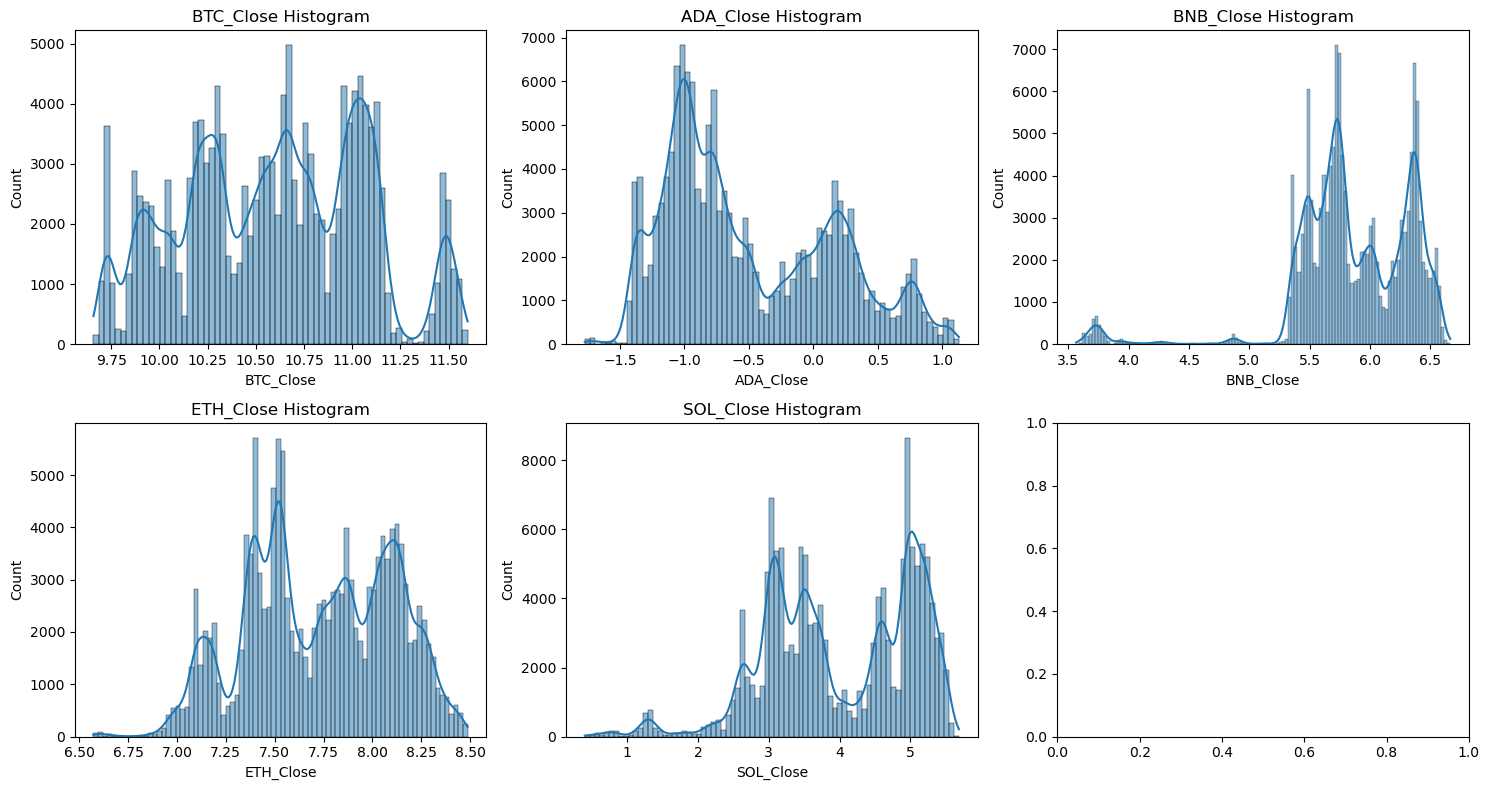

In [9]:
df_combined_log = np.log(df_combined)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, coin in enumerate(coins):
    sns.histplot(df_combined_log[coin], kde=True, ax=axes[i])
    axes[i].set_title(f"{coin} Histogram")
    
plt.tight_layout()
plt.show()                         

# 🔍 **Log-Transformed Price Distributions: Smoother & More Comparable**

## **🔹 Why Use a Log Transform?**
Applying a **logarithmic transformation** significantly **compresses extreme values** and **reduces long tails**, making it easier to compare cryptocurrencies that span vastly different price scales. 

---

## **📈 BTC & ETH: Multiple Growth Phases**
- **BTC clusters** strongly between **log values 9–11.5**, revealing distinct **growth cycles**.
- **ETH shows clear modes** between **6.5–8.5**, emphasizing periods of rapid expansion.

## **🟡 BNB & SOL: Accumulation & Distribution Cycles**
- **BNB:** Log values **3.5–6.5**, highlighting **phases of accumulation and sell-offs**.
- **SOL:** Spans **1–5**, reflecting **discrete waves of investor interest**.

## **🟦 ADA: Lower Nominal Prices, Clear Peaks**
- ADA’s log values **range from -1.5 to 1**, emphasizing its **lower price base**.
- Still exhibits **sharp peaks**, mirroring its **episodic surges** in value.

---

## **📌 Key Takeaways**
- The **log transform normalizes extreme price differences**, making **cross-asset comparisons easier**.
- BTC and ETH show **consistent long-term growth trends** with **distinct modal clustering**.
- BNB and SOL reflect **market cycles of accumulation & distribution**.
- ADA, despite its **lower price levels**, still follows **distinct appreciation patterns**.
- **More balanced distributions improve statistical modeling & time-series analysis**.

### 3.e Returns‐Based Regression


===== OLS Regression: ADA vs. BTC =====
                            OLS Regression Results                            
Dep. Variable:                    ADA   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                 1.090e+05
Date:                Sun, 23 Feb 2025   Prob (F-statistic):               0.00
Time:                        18:25:52   Log-Likelihood:             5.8055e+05
No. Observations:              144957   AIC:                        -1.161e+06
Df Residuals:                  144955   BIC:                        -1.161e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

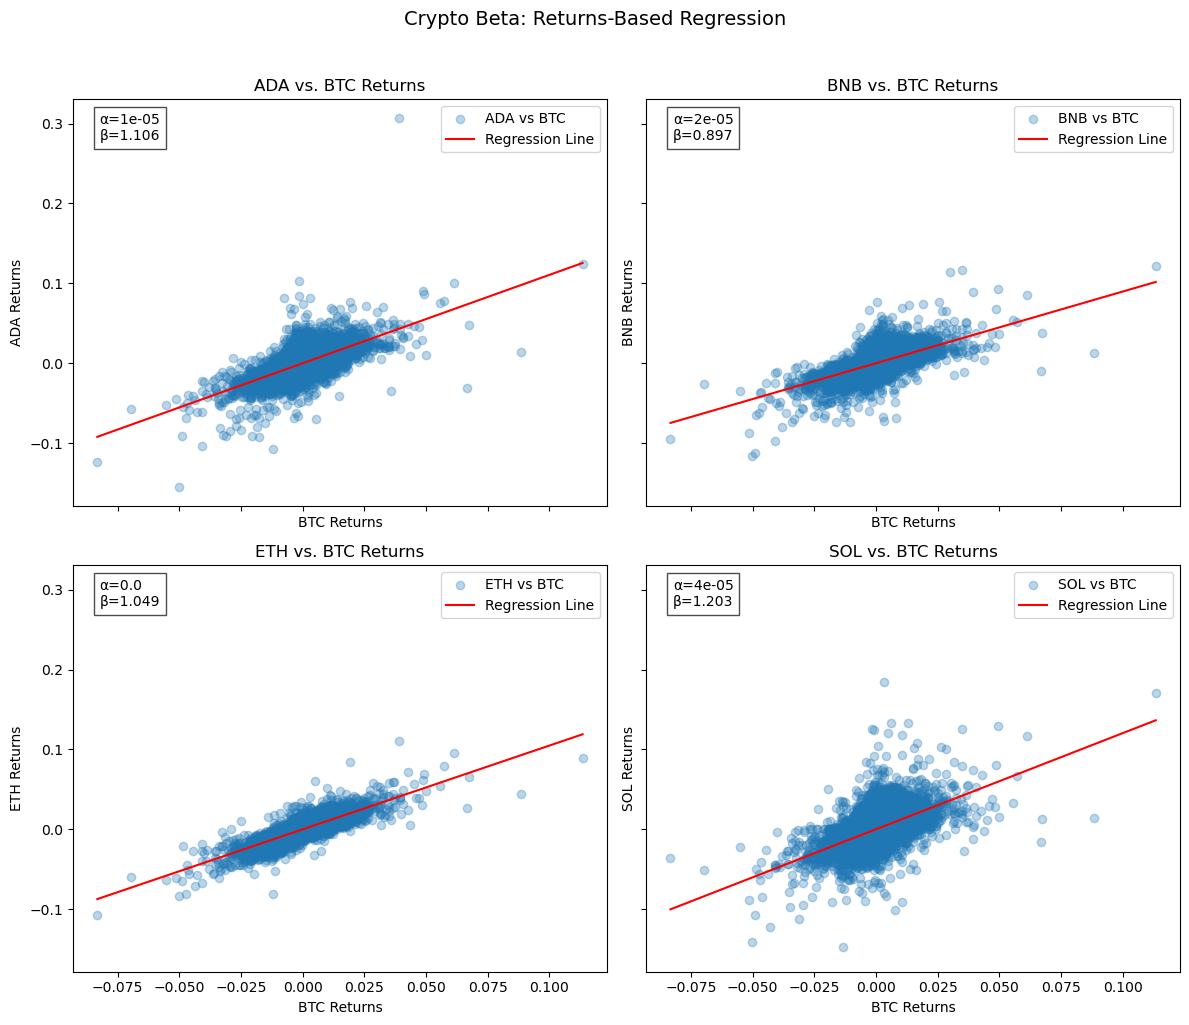

In [10]:
import statsmodels.api as sm

df_prices = pd.DataFrame({
    'BTC': df_btc.set_index('moment')['close'],
    'ADA': df_ada.set_index('moment')['close'],
    'BNB': df_bnb.set_index('moment')['close'],
    'ETH': df_eth.set_index('moment')['close'],
    'SOL': df_sol.set_index('moment')['close']
}).dropna()  

df_returns = df_prices.pct_change().dropna()
alts = ['ADA', 'BNB', 'ETH', 'SOL']
results = {}

for alt in alts:
    X = df_returns['BTC']
    y = df_returns[alt]
    
    X = sm.add_constant(X) 
    
    model = sm.OLS(y, X).fit()
    results[alt] = model     
    print(f"\n===== OLS Regression: {alt} vs. BTC =====")
    print(model.summary())

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten for easy iteration

for i, alt in enumerate(alts):
    ax = axes[i]
    
    X_no_const = df_returns['BTC']
    y = df_returns[alt]
    model = results[alt]
    
    ax.scatter(X_no_const, y, alpha=0.3, label=f"{alt} vs BTC")
    x_vals = np.linspace(X_no_const.min(), X_no_const.max(), 100)
    X_line = sm.add_constant(pd.Series(x_vals))  
    y_pred = model.predict(X_line)
    ax.plot(x_vals, y_pred, color='red', label="Regression Line")
    
    alpha_ = round(model.params.iloc[0], 5)  # FIXED
    beta_ = round(model.params.iloc[1], 3)   # FIXED
    ax.text(0.05, 0.9, f"α={alpha_}\nβ={beta_}", transform=ax.transAxes,
            fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_title(f"{alt} vs. BTC Returns")
    ax.set_xlabel("BTC Returns")
    ax.set_ylabel(f"{alt} Returns")
    ax.legend()

plt.suptitle("Crypto Beta: Returns-Based Regression", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 📊 BTC's Effect on Altcoins - Regression Analysis

## **1️⃣ Key Summary**
Each regression model estimates how **Bitcoin's returns (BTC)** impact the returns of **ADA, BNB, ETH, and SOL**.

- **Intercept (α)**: Represents the return of the altcoin when BTC return is **0%**.
- **Slope (β, "Beta")**: Measures the **sensitivity** of the altcoin to BTC movements.
  - If **β > 1** → Altcoin moves **more than BTC**.
  - If **β < 1** → Altcoin moves **less than BTC**.
  - If **β < 0** → Altcoin moves in **opposite direction** to BTC.
- **R² ("R-squared")**: Shows how much of the altcoin’s movement is **explained by BTC**.
  - **Higher R²** → BTC has a **stronger effect** on the altcoin.
  - **Lower R²** → Other factors drive the altcoin’s price.

---

## **🔹 Regression Results Breakdown**
| **Altcoin** | **α (Intercept)** | **β (BTC Sensitivity)** | **R² (BTC Influence)** | **Interpretation** |
|------------|-----------------|------------------|------------------|----------------------|
| **ADA** | `0.00001116` | **1.1065** | **0.429** | ADA moves **10.65% more** than BTC. |
| **BNB** | `0.00001818` | **0.8973** | **0.431** | BNB moves **less than BTC** (about 90%). |
| **ETH** | `0.00000368` | **1.0488** | **0.679** | ETH moves **almost the same** as BTC. BTC strongly influences ETH (high R²). |
| **SOL** | `0.00003976` | **1.2033** | **0.354** | SOL moves **20% more** than BTC but has weaker BTC influence. |

---

## **🔍 Detailed Analysis**
### **🔹 ADA vs. BTC**
- **β = 1.1065** → **ADA is 10.65% more volatile than BTC**.
- **R² = 0.429** → BTC explains **42.9%** of ADA's movements.
- **Takeaway**: BTC **significantly** affects ADA, but **over half of ADA’s movements come from other factors**.

### **🔹 BNB vs. BTC**
- **β = 0.8973** → **BNB moves slightly less than BTC** (90% of BTC’s movement).
- **R² = 0.431** → BTC explains **43.1%** of BNB’s movements.
- **Takeaway**: BNB **is less volatile than BTC**, likely due to Binance’s stability. BTC still **heavily** influences it.

### **🔹 ETH vs. BTC**
- **β = 1.0488** → **ETH moves almost 1:1 with BTC**.
- **R² = 0.679** → BTC explains **67.9%** of ETH’s price movement.
- **Takeaway**: BTC **strongly drives ETH**. If BTC moves, **ETH will almost certainly follow**.

### **🔹 SOL vs. BTC**
- **β = 1.2033** → **SOL is 20.33% more volatile than BTC**.
- **R² = 0.354** → BTC explains **only 35.4%** of SOL’s movements.
- **Takeaway**: SOL is **more volatile than BTC**, but **BTC has a weaker influence compared to other altcoins**.

---

## **🔥 Key Takeaways**
1. **BTC drives all altcoins, but to different extents:**
   - **ETH is most correlated with BTC (R² = 67.9%)**.
   - **SOL has the weakest BTC influence (R² = 35.4%)**.

2. **Higher beta means higher risk and reward:**
   - **SOL (β = 1.2033)** is **the most volatile**, meaning it moves more aggressively than BTC.
   - **BNB (β = 0.8973)** is **less risky**, meaning it doesn’t react as sharply.

3. **Other factors matter beyond BTC:**
   - The **R² values** (except ETH) are **below 50%**, meaning **altcoins have additional price drivers**.

---

## **📌 Summary**
- **BTC moves altcoins**, but some **more than others**.
- **ETH is most closely linked to BTC**.
- **SOL is the most volatile**.
- **BNB is the least volatile**.
- **If we trade altcoins, BTC movements are crucial to watch**.

---